# 08 · De la secant a la derivada

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/Derivades_BAT.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Entendre la derivada com un límit finit de pendents i distingir tres comportaments locals.

**Abans de començar:** quadern 07 i pendent d'una recta  
**Temps orientatiu:** 2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de Derivades_BAT.ipynb. Es conserven els originals en un arxiu separat.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Què significa la velocitat en un instant si la fórmula habitual divideix per un interval de temps?

**Al final ho has de poder explicar:** Relacionar la taxa de variació mitjana amb la pendent de la secant i el seu límit.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. La tangent no és simplement una recta que toca una corba
Prenem $A=(a,f(a))$ i $B=(a+h,f(a+h))$, amb $h\ne0$.
El pendent de la secant és
$$m_h=\frac{f(a+h)-f(a)}h.$$
Si aquest quocient té un límit **real finit**, el denotem $f'(a)$.
La tangent té equació $y=f(a)+f'(a)(x-a)$.

Per a $f(x)=x^2$, simplifica el quocient abans d'executar:
$$m_h=\frac{(a+h)^2-a^2}h=2a+h\longrightarrow2a.$$


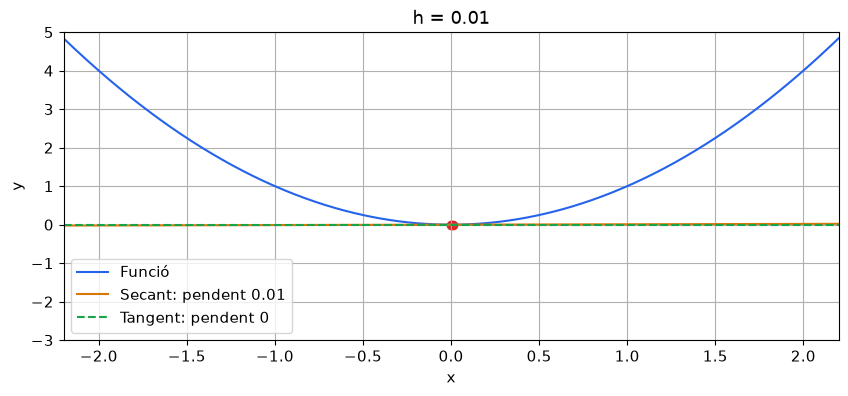

Quocient incremental = 0.01. Un valor finit de h no és el límit.


interactive(children=(Dropdown(description='tipus', options=('quadratica', 'absolut', 'arrel_cubica'), value='…

In [2]:
def funcio(tipus, x):
    if tipus == "quadratica": return np.asarray(x)**2
    if tipus == "absolut": return np.abs(x)
    if tipus == "arrel_cubica": return np.cbrt(x)
    raise ValueError("Funció desconeguda.")

def pendent_secant(tipus, a, h):
    if h == 0: raise ValueError("El pas h ha de ser diferent de zero.")
    if tipus == "quadratica": return 2*a+h  # forma algebraica estable
    return float((funcio(tipus, a+h)-funcio(tipus, a))/h)

def secant(tipus="quadratica", a=0.0, exponent=2, costat=1):
    h = costat * 10.0**(-exponent)
    m = pendent_secant(tipus, a, h)
    x = np.linspace(-2.2, 2.2, 601)
    fa = float(funcio(tipus, a))
    fig, ax = plt.subplots()
    ax.plot(x, funcio(tipus, x), color="#2563eb", label="Funció")
    ax.plot(x, fa+m*(x-a), color="#d97706", label=f"Secant: pendent {m:.5g}")
    ax.scatter([a, a+h], [fa, float(funcio(tipus, a+h))], color="#dc2626")
    if tipus == "quadratica":
        ax.plot(x, fa+2*a*(x-a), "--", color="#16a34a", label=f"Tangent: pendent {2*a:g}")
    ax.set(xlim=(-2.2, 2.2), ylim=(-3, 5), xlabel="x", ylabel="y", title=f"h = {h:g}")
    ax.legend(); plt.show()
    print(f"Quocient incremental = {m:.10g}. Un valor finit de h no és el límit.")
panell = explora(secant, tipus=["quadratica", "absolut", "arrel_cubica"],
                 a=(-1.5, 1.5, .25), exponent=(0, 6, 1), costat=[-1, 1])


## Laboratori animat · observa, atura i explica


### De la velocitat mitjana a la instantània

Un mòbil segueix $s(t)=t^2$ metres, amb t en segons. Entre t=1 i t=1+h, la velocitat mitjana és

$$\frac{s(1+h)-s(1)}{h}=\frac{(1+h)^2-1}{h}=2+h\quad(h\ne0).$$

| h (s) | Increment de posició (m) | Velocitat mitjana (m/s) |
|---|---|---|
| 1 | 3 | 3 |
| 0,1 | 0,21 | 2,1 |
| 0,01 | 0,0201 | 2,01 |

**No substituïm h=0 al quocient.** Estudiem a quin valor s'apropa quan l'interval es fa petit.
El triangle taronja del dibuix mostra $\Delta t=h$ i $\Delta s$. La seva proporció és la pendent.
La recta verda és la tangent de pendent 2 al punt (1,1).

A la dreta repetim la idea amb $|x|$ a 0. Les pendents són −1 per l'esquerra i 1 per la dreta:
els dos costats **no** acorden una única pendent.

**Prediu** la velocitat mitjana entre t=0,9 i t=1. **Pausa** abans del final i explica
què significa cada costat del triangle, incloent les unitats.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "La secant s'apropa a la tangent; una cantonada no té una sola pendent"
fotogrames_laboratori = list(range(18))

def estat_derivada(pas):
    h = .9*(.76**pas)
    return h, ((1+h)**2-1)/h, (1-(1-h)**2)/h

def dibuixa_laboratori(pas, axes):
    h, dreta, esquerra = estat_derivada(pas)
    ax, bx = axes
    x = np.linspace(-.2, 2.1, 300)
    ax.plot(x, x*x, color="#2563eb", label="s(t) = t²")
    ax.plot(x, 1+dreta*(x-1), color="#ea580c", label="Secant")
    ax.plot(x, 2*x-1, "--", color="#047857", label="Tangent: pendent 2")
    ax.plot([1, 1+h, 1+h], [1, 1, (1+h)**2], color="#ea580c", lw=2)
    ax.scatter([1, 1+h], [1, (1+h)**2], color="#ea580c", zorder=5)
    ax.set(xlim=(-.1, 2.1), ylim=(-.5, 4.5), xlabel="Temps t (s)", ylabel="Posició s (m)",
           title=f"h = {h:.5f} s; pendent = {dreta:.5f} m/s\nPel costat esquerre: {esquerra:.5f} m/s")
    ax.legend(fontsize=8, loc="upper left")
    x = np.linspace(-1, 1, 300)
    bx.plot(x, np.abs(x), color="#7c3aed", lw=2)
    bx.plot(x, x, "--", color="#ea580c", label="Pendent dreta: +1")
    bx.plot(x, -x, "--", color="#2563eb", label="Pendent esquerra: −1")
    bx.scatter([-h, 0, h], [h, 0, h], color=["#2563eb", "0.2", "#ea580c"], s=55, zorder=5)
    bx.set(xlim=(-1, 1), ylim=(-.15, 1.1), xlabel="x", ylabel="|x|",
           title="Contínua a 0, però no derivable\nLes pendents laterals continuen sent diferents")
    bx.legend(fontsize=8, loc="upper center")


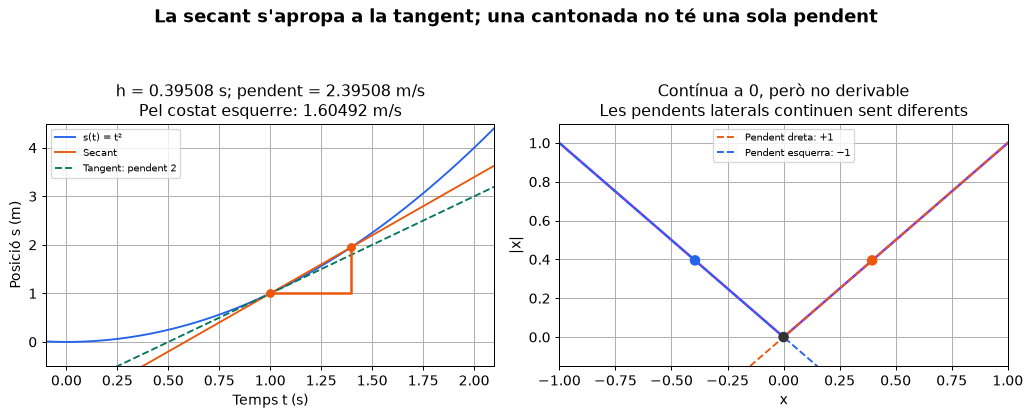

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(3)


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara dos triangles de la secant. Calcula Δs/Δt en tots dos: el triangle s'encongeix, però la proporció s'acosta a 2. Contrasta-ho amb les dues pendents de |x| a la dreta.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (0, 10)
etiquetes_comparacio = [f"h = {.9*.76**k:.5f}" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Per a s(t)=t², la velocitat mitjana de t=1 a t=1+h és...', 'opcions': ['2+h, si h≠0', 'h', '0, perquè h es fa petit'], 'correcta': 0, 'retorn': ['Correcte: ((1+h)²−1)/h=(2h+h²)/h=2+h.', 'En desenvolupar el quadrat també apareix el terme 2h.', 'Que numerador i denominador es facin petits no implica que el seu quocient tendeixi a 0.']}, {'enunciat': 'Què fem amb h per trobar la derivada?', 'opcions': ['El substituïm directament per 0 al quocient', 'Estudiem el límit amb h≠0', 'El deixem fix a 1'], 'correcta': 1, 'retorn': ['El quocient quedaria 0/0; cal estudiar el límit sense dividir per zero.', "Correcte: h s'apropa a 0, però no el substituïm al denominador.", 'Amb un interval fix calculem una taxa mitjana, no el límit instantani.']}, {'enunciat': 'La funció |x| a 0 és...', 'opcions': ['Discontínua', 'Derivable amb derivada 0', 'Contínua però no derivable'], 'correcta': 2, 'retorn': ["Les imatges s'apropen a 0 des dels dos costats: sí que és contínua.", 'Fer la mitjana de les pendents −1 i 1 no defineix una derivada.', 'Correcte: el valor i el límit coincideixen, però les pendents laterals són diferents.']}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


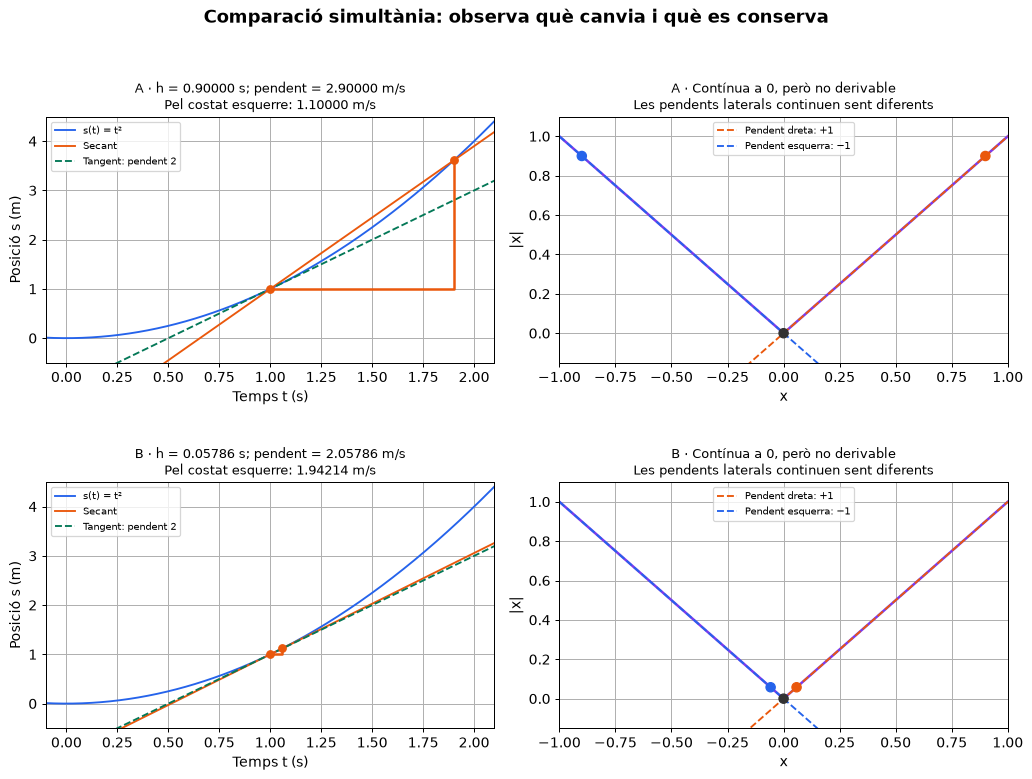

interactive(children=(Dropdown(description='Estat A:', options=(('h = 0.90000', 0), ('h = 0.68400', 1), ('h = …

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Canvia el punt a de 1 a 2 i després a −1. Prediu la pendent de x² i comprova-la amb quocients pels dos costats. Després prova abs(x) a a=0 i explica què impedeix obtenir una única derivada.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


h=1.000; pendent esquerra=3.000000; dreta=5.000000
h=0.500; pendent esquerra=3.500000; dreta=4.500000
h=0.100; pendent esquerra=3.900000; dreta=4.100000
h=0.050; pendent esquerra=3.950000; dreta=4.050000
h=0.010; pendent esquerra=3.990000; dreta=4.010000
h=0.005; pendent esquerra=3.995000; dreta=4.005000


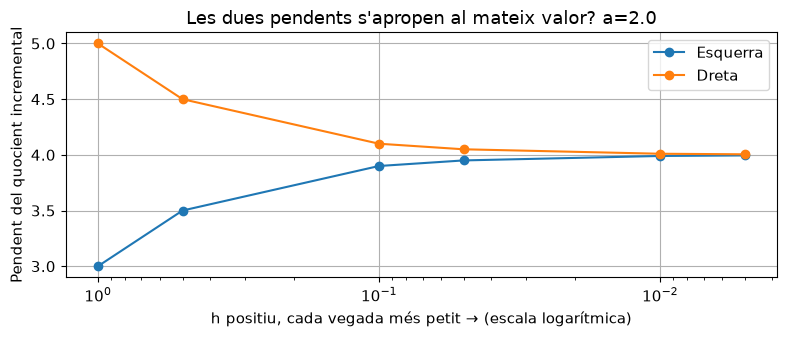

In [10]:
a_taller = 2.0
def funcio_taller(x):
    return x*x  # Prova després abs(x), amb a_taller = 0.
pendents_esquerres, pendents_dretes = [], []
increments = [1, .5, .1, .05, .01, .005]
for h in increments:
    dreta = (funcio_taller(a_taller+h)-funcio_taller(a_taller))/h
    esquerra = (funcio_taller(a_taller-h)-funcio_taller(a_taller))/(-h)
    pendents_dretes.append(dreta); pendents_esquerres.append(esquerra)
    print(f"h={h:.3f}; pendent esquerra={esquerra:.6f}; dreta={dreta:.6f}")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogx(increments, pendents_esquerres, "o-", label="Esquerra")
ax.semilogx(increments, pendents_dretes, "o-", label="Dreta")
ax.invert_xaxis()
ax.set(xlabel="h positiu, cada vegada més petit → (escala logarítmica)",
       ylabel="Pendent del quocient incremental", title=f"Les dues pendents s'apropen al mateix valor? a={a_taller}")
ax.legend(); plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Per a s(t)=t², la velocitat mitjana de t=1 a t=1+h és...**

- A. 2+h, si h≠0
- B. h
- C. 0, perquè h es fa petit

**2. Què fem amb h per trobar la derivada?**

- A. El substituïm directament per 0 al quocient
- B. Estudiem el límit amb h≠0
- C. El deixem fix a 1

**3. La funció |x| a 0 és...**

- A. Discontínua
- B. Derivable amb derivada 0
- C. Contínua però no derivable

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Desenvolupa $(2+h)^2-4$ i dedueix la derivada de $x^2$ al punt 2 a partir del quocient incremental.
2. Per a $s(t)=3t+2$, calcula dues velocitats mitjanes amb intervals diferents. Quina és la instantània?
3. Per què el triangle del dibuix s'encongeix, però la seva proporció no tendeix a 0?
4. Dona un exemple de funció contínua que no sigui derivable i justifica'l amb pendents laterals.


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

El quocient és $4+h$ i el límit és 4. Per a $s(t)=3t+2$, totes les velocitats
mitjanes i la instantània són 3 m/s. El quocient de dues quantitats que tendeixen a 0
no ha de tendir a 0: aquí tendeix a 2. $|x|$ és contínua a 0 però té pendents laterals −1 i 1.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. Al punt a=0: tres resultats diferents
* $x^2$: $m_h=h\to0$ pels dos costats. Derivada igual a 0.
* $|x|$: $m_h=1$ per h>0 i $m_h=-1$ per h<0. No hi ha un únic límit.
* $\sqrt[3]{x}$: $m_h=|h|^{-2/3}\to+\infty$. Hi ha tangent vertical,
  però no una derivada real finita a 0.

Les tres funcions són contínues a 0. **Continuïtat no implica derivabilitat.**


In [13]:
for tipus in ("quadratica", "absolut", "arrel_cubica"):
    print("\n", tipus)
    for h in (0.1, 0.001, -0.001, -0.1):
        print(f"h={h:8g}: pendent={pendent_secant(tipus, 0, h):12.6g}")



 quadratica
h=     0.1: pendent=         0.1
h=   0.001: pendent=       0.001
h=  -0.001: pendent=      -0.001
h=    -0.1: pendent=        -0.1

 absolut
h=     0.1: pendent=           1
h=   0.001: pendent=           1
h=  -0.001: pendent=          -1
h=    -0.1: pendent=          -1

 arrel_cubica
h=     0.1: pendent=     4.64159
h=   0.001: pendent=         100
h=  -0.001: pendent=         100
h=    -0.1: pendent=     4.64159


## 3. Un pont amb Cauchy, amb una precaució
Si la derivada existeix, els pendents calculats al llarg de qualsevol successió
$h_n\to0$, $h_n\ne0$, convergeixen al mateix nombre i són de Cauchy.
**Una sola successió de pendents de Cauchy no demostra la derivabilitat:**
per a $|x|$, els passos $h_n=1/n$ donen sempre pendent 1, però els passos negatius donen −1.

## 4. Regles i correccions conceptuals
| Funció | Derivada i condicions |
|---|---|
| $x^3$ | $3x^2$ |
| $\sin x$ | $\cos x$, amb angles en radians |
| $\cos x$ | $-\sin x$ |
| $\ln x$ | $1/x$, per a x>0 |
| $g(h(x))$ | $g'(h(x))h'(x)$, quan les derivades necessàries existeixen |

La identitat correcta és $\cos^2x-1=-\sin^2x$.
Si $f'(a)=0$, a no ha de ser un extrem: $f(x)=x^3$ al punt 0 és un contraexemple.
Si $f''(a)=0$, tampoc podem concloure que la funció sigui una recta en un entorn d'a.


In [14]:
# L'arrodoniment pot malmetre el quocient calculat per una resta de nombres propers.
a = 1.0
print("h          quocient directe       expressió 2a+h")
for h in (1e-2, 1e-6, 1e-10, 1e-14, 1e-17):
    directe = ((a+h)**2-a**2)/h
    print(f"{h:9.1e}  {directe:20.12g}  {2*a+h:20.12g}")


h          quocient directe       expressió 2a+h
  1.0e-02                  2.01                  2.01
  1.0e-06         2.00000099992              2.000001
  1.0e-10         2.00000016548          2.0000000001
  1.0e-14         1.99840144433                     2
  1.0e-17                     0                     2


## Activitats
1. Troba l'equació de la tangent de $x^2$ al punt a=1 i al punt a=−1.
2. Explica per què no podem substituir h=0 al quocient incremental.
3. Per a $|x|$, canvia a de 0 a 1. Què passa amb els pendents quan h és petit?
4. **Ampliació:** demostra que ser derivable a a implica ser contínua a a,
   escrivint $f(a+h)-f(a)=h\,[f(a+h)-f(a)]/h$.
5. Escriu una conclusió sobre el recorregut: per què necessitem ℝ abans d'estudiar límits i derivades?

<details><summary>Comprovació</summary>

Les tangents són $y=2x-1$ i $y=-2x-1$. A a=1, el valor absolut coincideix localment
amb x, i la derivada és 1. En la demostració de continuïtat, el quocient té límit
finit i el factor h tendeix a zero. Els experiments numèrics són evidència;
les identitats i els arguments de límits proporcionen les justificacions.
</details>


**Navegació:** [Anterior](07_Limits_Continuitat.ipynb) · [Índex i guia](README.md)
